## Relaxation Time by Segment

The relaxation time τ = 1/γ measures how long it takes a customer to return to equilibrium after a perturbation.

- τ small -> customer that recovers quickly (resilient) or falls quickly (volatile)
- τ large -> slow-responding customer, could be loyal or silent accumulating dissatisfaction

In [6]:
import os
import sqlite3
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

warnings.filterwarnings('ignore')

ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
sys.path.insert(0, ROOT)
os.chdir(os.path.join(ROOT, 'notebooks'))

from src.physics import solve_trajectory, step_perturbation 
from src.visualization import PALETTE, plot_physical_states, plot_relaxation, set_style  

set_style()

try:
    LIFELINES_OK = True
except Exception:
    LIFELINES_OK = False

DATA_DIR = os.path.join(ROOT, 'data')
df_clean = pd.read_csv(os.path.join(DATA_DIR, 'telco_clean.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'telco_features.csv'))
df_final = pd.read_csv(os.path.join(DATA_DIR, 'telco_final.csv'))
df = df_features.copy()
df_model = pd.get_dummies(df, columns=['Contract','PaymentMethod','InternetService'], drop_first=True)

conn = sqlite3.connect(':memory:')
df.to_sql('telco', conn, if_exists='replace', index=False)
df_clean.to_sql('telco_clean', conn, if_exists='replace', index=False)

print(f'Ready: {len(df):,} customers | churn rate {df.Churn_bin.mean():.1%}')

Ready: 7,043 customers | churn rate 26.5%


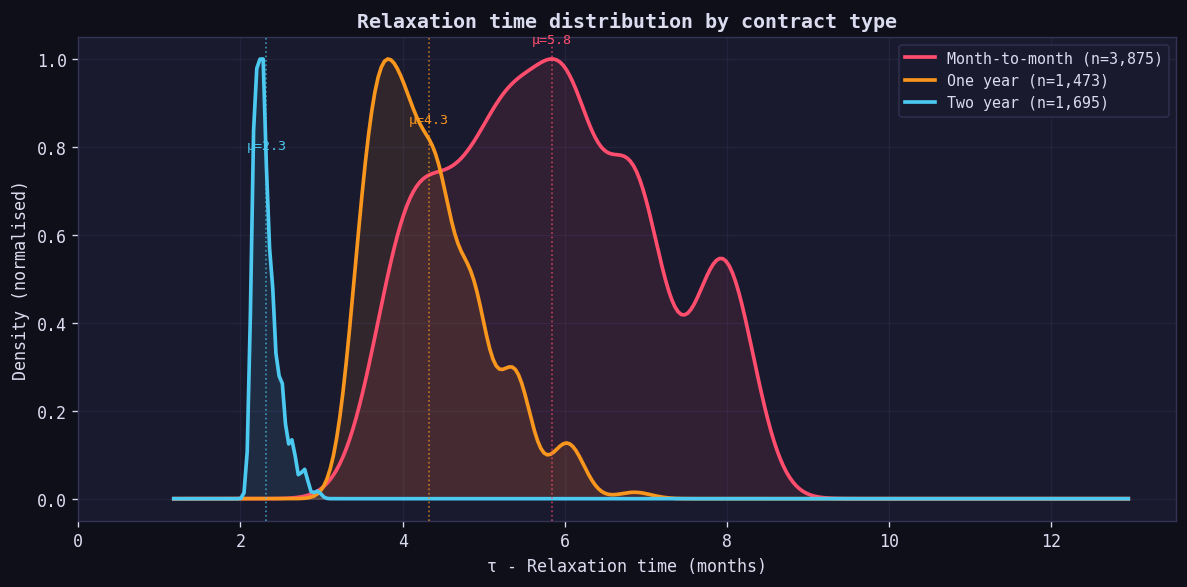

In [7]:
fig, ax = plt.subplots(figsize=(10,5))
plot_relaxation(df, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '05_relaxation.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

In [8]:
# Churn rate by resilience
resumen = df.groupby('resilience').agg(total=('Churn_bin','count'),churn_rate=('Churn_bin','mean'), tau_median=('tau','median'), E0_median=('E0','median')).round(4)
print('Churn Rate by Resilience')
resumen
print(resumen.to_string() if hasattr(resumen,'to_string') else str(resumen))


Churn Rate by Resilience
            total  churn_rate  tau_median  E0_median
resilience                                          
High         2328      0.0408      2.3849     0.8022
Low          2115      0.5608      6.8587     0.6103
Medium       2600      0.2262      4.8591     0.7773


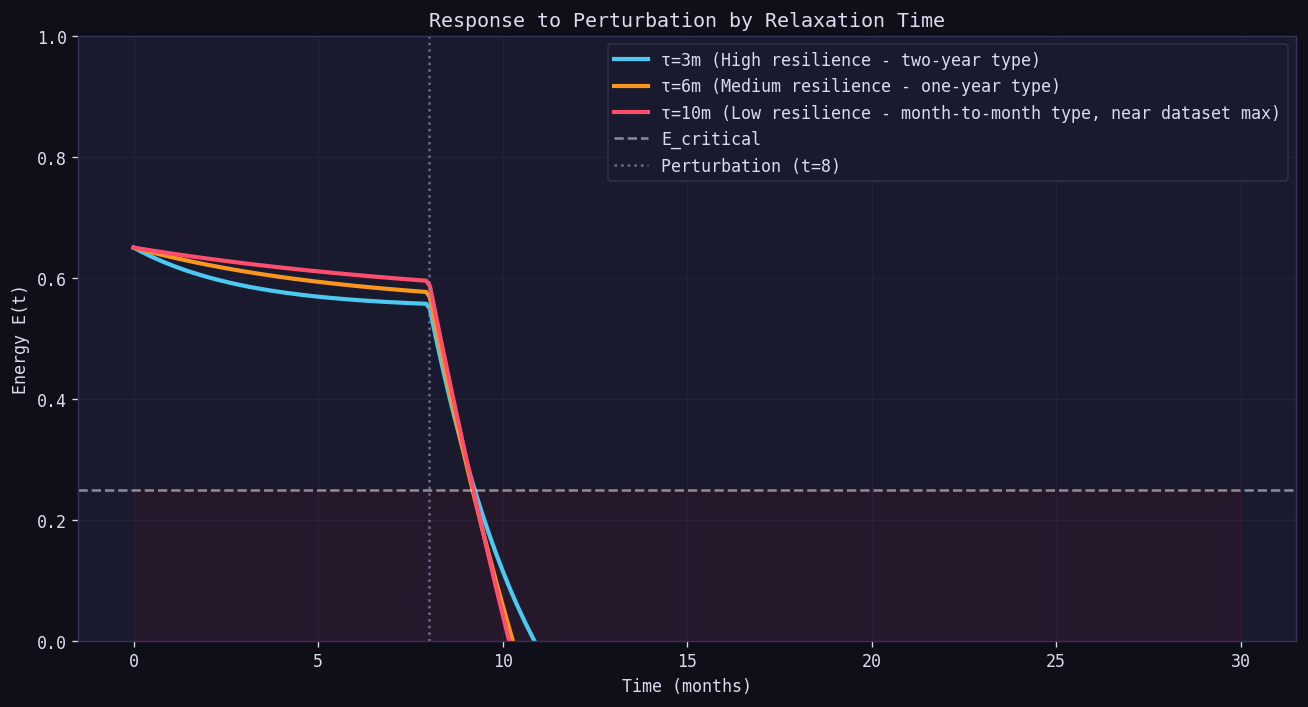

In [9]:
# Simulation: same perturbation on customers with different τ

fig, ax = plt.subplots(figsize=(11,6))
t_eval = np.linspace(0, 30, 300)

profiles = [
    {'tau': 3, 'color': PALETTE['no_churn'], 'label': 'τ=3m (High resilience - two-year type)'},
    {'tau': 6, 'color': PALETTE['accent'], 'label': 'τ=6m (Medium resilience - one-year type)'},
    {'tau': 10, 'color': PALETTE['churn'], 'label': 'τ=10m (Low resilience - month-to-month type, near dataset max)'},]

for p in profiles:
    gamma = 1/p['tau']
    sol = solve_trajectory(0.65, gamma, lambda t: step_perturbation(t, 8, 0.3), (0,30), t_eval)
    ax.plot(sol.t, sol.y[0], color=p['color'], linewidth=2.5, label=p['label'])

ax.axhline(0.25, color='white', linestyle='--', alpha=0.5, linewidth=1.5, label='E_critical')
ax.axvline(8, color=PALETTE['neutral'], linestyle=':', alpha=0.7, label='Perturbation (t=8)')
ax.fill_between(t_eval, 0, 0.25, color='red', alpha=0.05)
ax.set_xlabel('Time (months)')
ax.set_ylabel('Energy E(t)')
ax.set_title('Response to Perturbation by Relaxation Time')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '05_perturbation_response.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

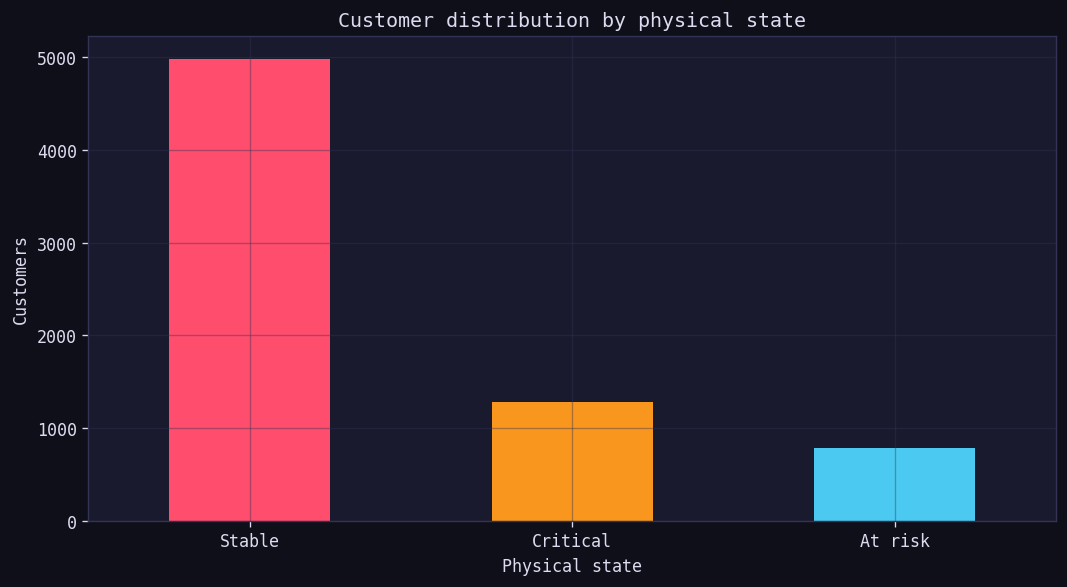

In [10]:
# Customer segmentation by resilience and churn
fig, ax = plt.subplots(figsize=(9,5))
plot_physical_states(df, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', '05_physical_states.png'), dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()